In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# `polymarket_data` — Tutorial

This notebook walks through the full workflow for fetching and analysing
Polymarket trade data using the `PolymarketData` class.

**Topics covered**
1. Resolve a market slug to metadata
2. Fetch raw trade-by-trade data
3. Compute OHLCV + VWAP price bars
4. Switch to the Polars backend

---

In [25]:
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from polymarket_data import PolymarketData

## 1. Resolve market metadata

Every Polymarket market has a URL slug — the last segment of its
`polymarket.com` URL.  `get_market()` turns a slug into a `MarketInfo`
object containing the question text, outcome labels, and the on-chain
token IDs needed for data fetching.

In [37]:
import requests

r = requests.get("https://gamma-api.polymarket.com/events?slug=bun-aug-koe-2026-02-27&limit=1")

In [38]:
r.json()

[{'id': '208548',
  'ticker': 'bun-aug-koe-2026-02-27',
  'slug': 'bun-aug-koe-2026-02-27',
  'title': 'FC Augsburg vs. 1. FC Köln',
  'description': 'This event is for the upcoming Bundesliga game, scheduled for Friday, February 27, 2026 between FC Augsburg and 1. FC Köln.',
  'resolutionSource': 'https://www.bundesliga.com/en/bundesliga',
  'startDate': '2026-02-14T05:05:49.232238Z',
  'creationDate': '2026-02-14T05:05:49.232233Z',
  'endDate': '2026-02-27T19:30:00Z',
  'image': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/league-bun.jpg',
  'icon': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/league-bun.jpg',
  'active': True,
  'closed': False,
  'archived': False,
  'new': False,
  'featured': False,
  'restricted': True,
  'liquidity': 174515.6585,
  'volume': 1811474.680727,
  'openInterest': 0,
  'createdAt': '2026-02-14T05:00:06.451155Z',
  'updatedAt': '2026-02-27T20:18:03.671136Z',
  'competitive': 0.9869476177551876,
  'volume24hr': 84044.83061799996,
  'v

In [50]:
SLUG = "epl-wol-ast-2026-02-27-ast"

pm = PolymarketData()
market = pm.get_market(SLUG)

print(f"Question  : {market.question}")
print(f"Outcomes  : {market.outcomes}")
print(f"Token IDs : {[tid[:12] + '...' for tid in market.token_ids]}")

Question  : Will Aston Villa FC win on 2026-02-27?
Outcomes  : ['Yes', 'No']
Token IDs : ['924892601690...', '273724287144...']


## 2. Fetch raw trades

`fetch_trades()` returns a DataFrame with one row per fill, scoped to a
single outcome token.  Specify the outcome by label (`outcome="Yes"`) or
by index (`outcome_index=0`).  The default is index 0 (the first outcome,
conventionally Yes on Polymarket).

The `backend` parameter selects whether you get back a **pandas** or
**polars** DataFrame.

In [51]:
START = datetime(2026, 2, 27, tzinfo=timezone.utc)
END   = datetime(2026, 2, 28, tzinfo=timezone.utc)

trades = pm.fetch_trades(
    slug=SLUG,
    start_time=START,
    end_time=END,
    outcome="Yes",
    backend="pandas",
)

print(f"{len(trades):,} trades  |  "
      f"total volume: {trades['size'].sum():,.0f} shares  |  "
      f"price range: [{trades['price'].min():.4f}, {trades['price'].max():.4f}]")
trades.head()

3,548 trades  |  total volume: 4,085,246 shares  |  price range: [0.5100, 0.5700]


,timestamp,price,size,side,outcome
0,2026-02-27 00:16:30+00:00,0.52,20.000000,BUY,Yes
1,2026-02-27 00:17:30+00:00,0.52,9.615383,BUY,Yes
2,2026-02-27 00:17:50+00:00,0.52,173.076922,BUY,Yes
3,2026-02-27 00:20:32+00:00,0.52,38.461537,BUY,Yes
4,2026-02-27 00:25:26+00:00,0.51,143.000000,BUY,Yes


In [52]:
trades.head(10)

,timestamp,price,size,side,outcome
0,2026-02-27 00:16:30+00:00,0.52,20.000000,BUY,Yes
1,2026-02-27 00:17:30+00:00,0.52,9.615383,BUY,Yes
2,2026-02-27 00:17:50+00:00,0.52,173.076922,BUY,Yes
3,2026-02-27 00:20:32+00:00,0.52,38.461537,BUY,Yes
4,2026-02-27 00:25:26+00:00,0.51,143.000000,BUY,Yes
5,2026-02-27 00:29:08+00:00,0.52,100.000000,BUY,Yes
6,2026-02-27 00:30:36+00:00,0.51,5.760000,BUY,Yes
7,2026-02-27 00:30:36+00:00,0.51,5.760000,SELL,Yes
8,2026-02-27 00:35:20+00:00,0.52,29.370000,BUY,Yes
9,2026-02-27 00:38:36+00:00,0.52,5.000000,BUY,Yes


### Summary statistics

In [53]:
trades.groupby("side").agg(
    trade_count=("price", "count"),
    volume=("size", "sum"),
    avg_price=("price", "mean"),
    median_size=("size", "median"),
).round(4)

,trade_count,volume,avg_price,median_size
side,,,,
BUY,3255,3.962731e+06,0.5419,28.3019
SELL,293,1.225142e+05,0.5431,17.5439


## 3. Price series — OHLCV + VWAP

`price_series()` aggregates the raw trades into time bars and returns a
DataFrame with the following columns:

| Column | Description |
|---|---|
| `open` | Price of the first trade in the interval |
| `high` | Highest trade price in the interval |
| `low` | Lowest trade price in the interval |
| `close` | Price of the last trade in the interval |
| `vwap` | Volume-weighted average price: Σ(price × size) / Σ(size) |
| `volume` | Total shares traded in the interval |
| `trade_count` | Number of fills in the interval |

The timestamp is the **index** for pandas and the **first column** for
polars, aligned to natural UTC boundaries (hour start, midnight, etc.).

`fill_gaps=True` (default) includes empty bars with `NaN` prices and
zero volume for intervals with no trades.

In [54]:
trades[trades["timestamp"] >= "2026-02-17T04:00:00+00:00"]

,timestamp,price,size,side,outcome
0,2026-02-27 00:16:30+00:00,0.52,20.000000,BUY,Yes
1,2026-02-27 00:17:30+00:00,0.52,9.615383,BUY,Yes
2,2026-02-27 00:17:50+00:00,0.52,173.076922,BUY,Yes
3,2026-02-27 00:20:32+00:00,0.52,38.461537,BUY,Yes
4,2026-02-27 00:25:26+00:00,0.51,143.000000,BUY,Yes
...,...,...,...,...,...
3543,2026-02-27 20:21:55+00:00,0.54,2248.320000,SELL,Yes
3544,2026-02-27 20:21:55+00:00,0.54,30.000000,BUY,Yes
3545,2026-02-27 20:21:55+00:00,0.54,30.000000,BUY,Yes
3546,2026-02-27 20:21:55+00:00,0.54,205.060000,BUY,Yes


In [59]:
bars = pm.price_series(
    slug=SLUG,
    start_time=START,
    end_time=END,
    freq="5min",
    outcome="Yes",
    fill_gaps=True,
    backend="pandas",
)

print(f"{len(bars)} hourly bars  |  "
      f"{bars['trade_count'].gt(0).sum()} with trades  |  "
      f"{bars['trade_count'].eq(0).sum()} empty")
bars.dropna().tail(10)

288 hourly bars  |  223 with trades  |  65 empty


,open,high,low,close,vwap,volume,trade_count
timestamp,,,,,,,
2026-02-27 19:35:00+00:00,0.55,0.56,0.54000,0.54,0.551753,1.399062e+04,26
2026-02-27 19:40:00+00:00,0.56,0.56,0.55814,0.56,0.559986,7.099411e+03,18
2026-02-27 19:45:00+00:00,0.56,0.57,0.55000,0.57,0.561914,2.083671e+06,318
2026-02-27 19:50:00+00:00,0.56,0.57,0.56000,0.56,0.569114,1.779015e+05,135
2026-02-27 19:55:00+00:00,0.56,0.57,0.55000,0.56,0.568473,6.208761e+05,106
2026-02-27 20:00:00+00:00,0.57,0.57,0.54000,0.55,0.569546,3.135306e+05,44
2026-02-27 20:05:00+00:00,0.55,0.57,0.55000,0.56,0.560174,2.319814e+04,69
2026-02-27 20:10:00+00:00,0.55,0.57,0.54000,0.54,0.554502,4.152547e+03,62
2026-02-27 20:15:00+00:00,0.54,0.56,0.53000,0.55,0.549020,2.154886e+04,65


### Visualise the price bars

Plot the VWAP series with the high–low range shaded and volume as a bar
chart underneath.

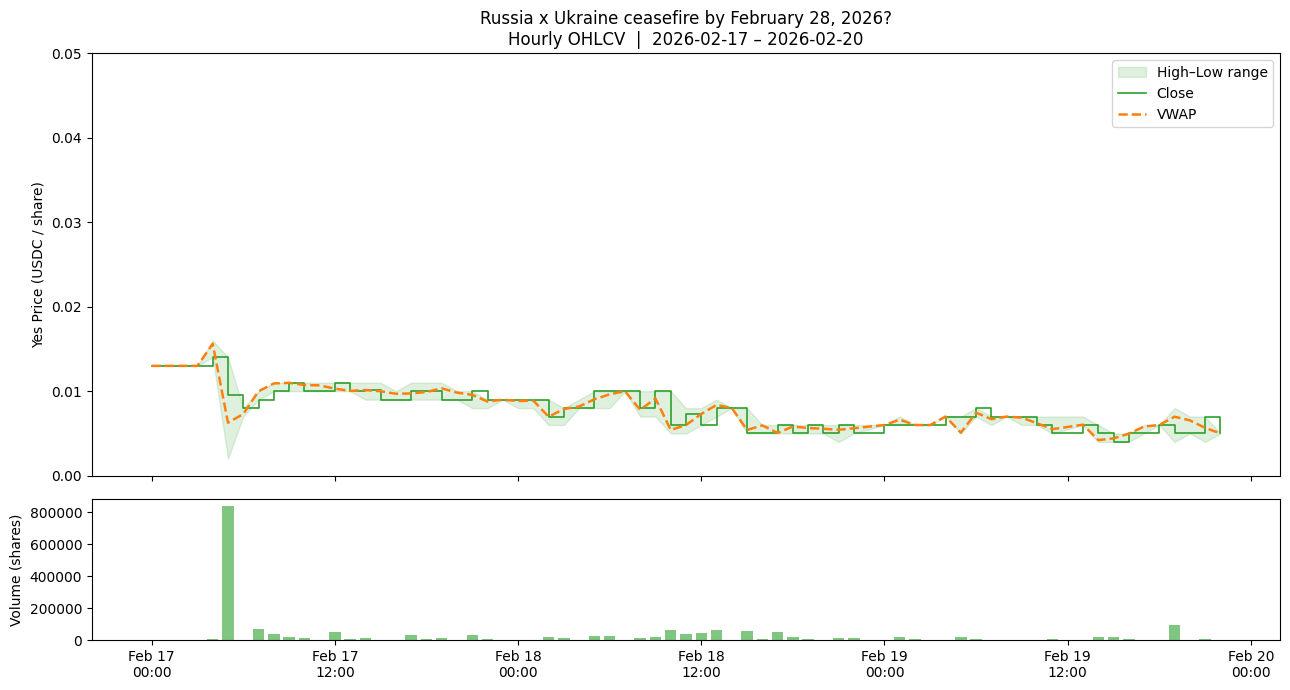

In [8]:
active = bars[bars["trade_count"] > 0]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# — Price panel —
ax1.fill_between(
    active.index, active["low"], active["high"],
    alpha=0.15, color="tab:green", label="High–Low range",
)
ax1.step(
    active.index, active["close"],
    where="post", color="tab:green", linewidth=1.2, label="Close",
)
ax1.plot(
    active.index, active["vwap"],
    color="tab:orange", linewidth=1.8, linestyle="--", label="VWAP",
)
ax1.set_ylabel("Yes Price (USDC / share)")
ax1.set_title(
    f"{market.question}\n"
    f"Hourly OHLCV  |  {START.date()} – {END.date()}"
)
ax1.legend(loc="upper right")
ax1.set_ylim(0, 0.05)

# — Volume panel —
bar_width = pd.Timedelta("45min")
ax2.bar(
    active.index, active["volume"],
    width=bar_width, color="tab:green", alpha=0.6,
)
ax2.set_ylabel("Volume (shares)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

fig.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()

### `fill_gaps=False` — only bars with trades

Pass `fill_gaps=False` to drop empty intervals entirely.  Useful for
sparse markets or when you want to feed data into a model without NaNs.

In [9]:
bars_no_gaps = pm.price_series(
    slug=SLUG,
    start_time=START,
    end_time=END,
    freq="1h",
    outcome="Yes",
    fill_gaps=False,
    backend="pandas",
)

print(f"{len(bars_no_gaps)} bars (all with ≥1 trade)")
bars_no_gaps.describe().round(4)

69 bars (all with ≥1 trade)


,open,high,low,close,vwap,volume,trade_count
count,69.0000,69.0000,69.0000,69.0000,69.0000,69.0000,69.0000
mean,0.0080,0.0087,0.0072,0.0079,0.0080,27031.7616,13.4493
std,0.0024,0.0024,0.0026,0.0024,0.0025,101250.7726,14.3860
min,0.0050,0.0050,0.0020,0.0040,0.0042,4.0700,1.0000
25%,0.0060,0.0070,0.0050,0.0060,0.0060,997.4733,6.0000
50%,0.0080,0.0080,0.0070,0.0080,0.0073,6056.9256,10.0000
75%,0.0100,0.0100,0.0090,0.0100,0.0098,19996.3833,19.0000
max,0.0155,0.0160,0.0140,0.0140,0.0156,839331.3041,107.0000


## 4. Polars backend

Both `fetch_trades()` and `price_series()` accept `backend="polars"` to
return a **Polars** DataFrame.  The timestamp is a column (not an index)
and the frequency string uses the same pandas-style notation.

In [12]:
import polars as pl

bars_pl = pm.price_series(
    slug=SLUG,
    start_time=START,
    end_time=END,
    freq="1h",
    outcome="Yes",
    fill_gaps=True,
    backend="polars",
)

print(bars_pl.schema)
bars_pl.head(10)

Schema({'timestamp': Datetime(time_unit='us', time_zone='UTC'), 'open': Float64, 'high': Float64, 'low': Float64, 'close': Float64, 'vwap': Float64, 'volume': Float64, 'trade_count': UInt32})


timestamp,open,high,low,close,vwap,volume,trade_count
"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,u32
2026-02-17 00:00:00 UTC,0.013,0.013,0.013,0.013,0.013,71.42,2
2026-02-17 01:00:00 UTC,0.013,0.013,0.013,0.013,0.013,28.0,2
2026-02-17 02:00:00 UTC,0.013,0.013,0.013,0.013,0.013,133.900692,1
2026-02-17 03:00:00 UTC,0.013,0.013,0.013,0.013,0.013,489.08,1
2026-02-17 04:00:00 UTC,0.015464,0.016,0.014,0.014,0.015615,6056.925642,7
2026-02-17 05:00:00 UTC,0.009,0.014,0.002,0.009547,0.006276,839331.304098,107
2026-02-17 06:00:00 UTC,0.007,0.008,0.007,0.008,0.007298,1997.92,8
2026-02-17 07:00:00 UTC,0.009,0.01,0.009,0.009,0.009994,70024.27111,27
2026-02-17 08:00:00 UTC,0.01,0.011,0.01,0.01,0.010915,36802.932726,24


In [11]:
# Polars makes filtering and chaining easy
(
    bars_pl
    .filter(pl.col("trade_count") > 0)
    .select(["timestamp", "vwap", "volume", "trade_count"])
    .sort("volume", descending=True)
    .head(5)
)

timestamp,vwap,volume,trade_count
"datetime[μs, UTC]",f64,f64,u32
2026-02-17 04:00:00 UTC,0.006624,917410.42085,149
2026-02-18 12:00:00 UTC,0.007061,160671.350937,57
2026-02-18 08:00:00 UTC,0.006341,133711.213718,103
2026-02-19 16:00:00 UTC,0.006785,106482.12375,46
2026-02-18 16:00:00 UTC,0.005343,83750.517058,55
